In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [ ]:
#download and preparing the data
data="https://github.com/ageron/data/raw/main/"
lifesat=pd.read_csv(data+"lifesat/lifesat.csv")


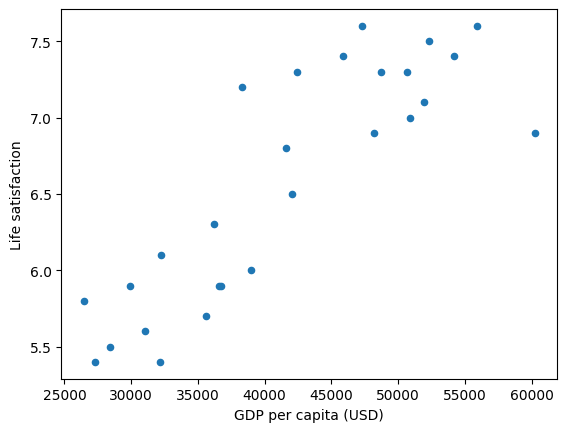

[[6.30103401]]


In [ ]:
x=lifesat[["GDP per capita (USD)"]].values
y=lifesat[["Life satisfaction"]].values

lifesat.plot(kind="scatter",x="GDP per capita (USD)",y="Life satisfaction")


plt.show()
#selection of model
model=LinearRegression()
#training of model
model.fit(x,y)
#making of predictions
x_new=[[37_646]]



print( model.predict(x_new))


If you had used an instance-based learning algorithm instead, you would have found that Israel
has the closest GDP per capita to that of Cyprus ($38,341), and since the OECD data tells us
that Israelis’ life satisfaction is 7.2, you would have predicted a life satisfaction of 7.2 for
Cyprus. If you zoom out a bit and look at the two next-closest countries, you will find
Lithuania and Slovenia, both with a life satisfaction of 5.9. Averaging these three values, you
get 6.33, which is pretty close to your model-based prediction. This simple algorithm is called
k-nearest neighbors regression (in this example, k = 3).

KNeighborsRegressor is a non-parametric regression method that predicts the target value for a new data point by averaging the target values of its K nearest neighbors in the feature space.


In [ ]:
#lets use kneighbour model
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)
model.fit(x,y)
x_new1=[[37_646]]
print(model.predict(x_new1))

[[6.33333333]]


Rather than manually downloading and decompressing the data, it’s usually
preferable to write a function that does it for you. This is useful in particular if
the data changes regularly: you can write a small script that uses the function to
fetch the latest data (or you can set up a scheduled job to do that automatically at
regular intervals). Automating the process of fetching the data is also useful if
you need to install the dataset on multiple machines.

In [ ]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
      Path("datasets").mkdir(parents=True, exist_ok=True)
      url = "https://github.com/ageron/data/raw/main/housing.tgz"
      urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets")
    return pd.read_csv(Path("datasets/housing/housing.csv"))
housing = load_housing_data()

/tmp/ipython-input-2684438460.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  housing_tarball.extractall(path="datasets")


In [ ]:
housing

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


You can find out what categories exist and how many
districts belong to each category by using the value_counts() method:

In [ ]:
housing['ocean_proximity'].value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


The describe() method shows a summary of
the numerical attributes

In [ ]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Another quick way to get a feel of the type of data you are dealing with is to plot
a histogram for each numerical attribute. A histogram shows the number of
instances (on the vertical axis) that have a given value range (on the horizontal
axis). You can either plot this one attribute at a time, or you can call the hist()
method on the whole dataset

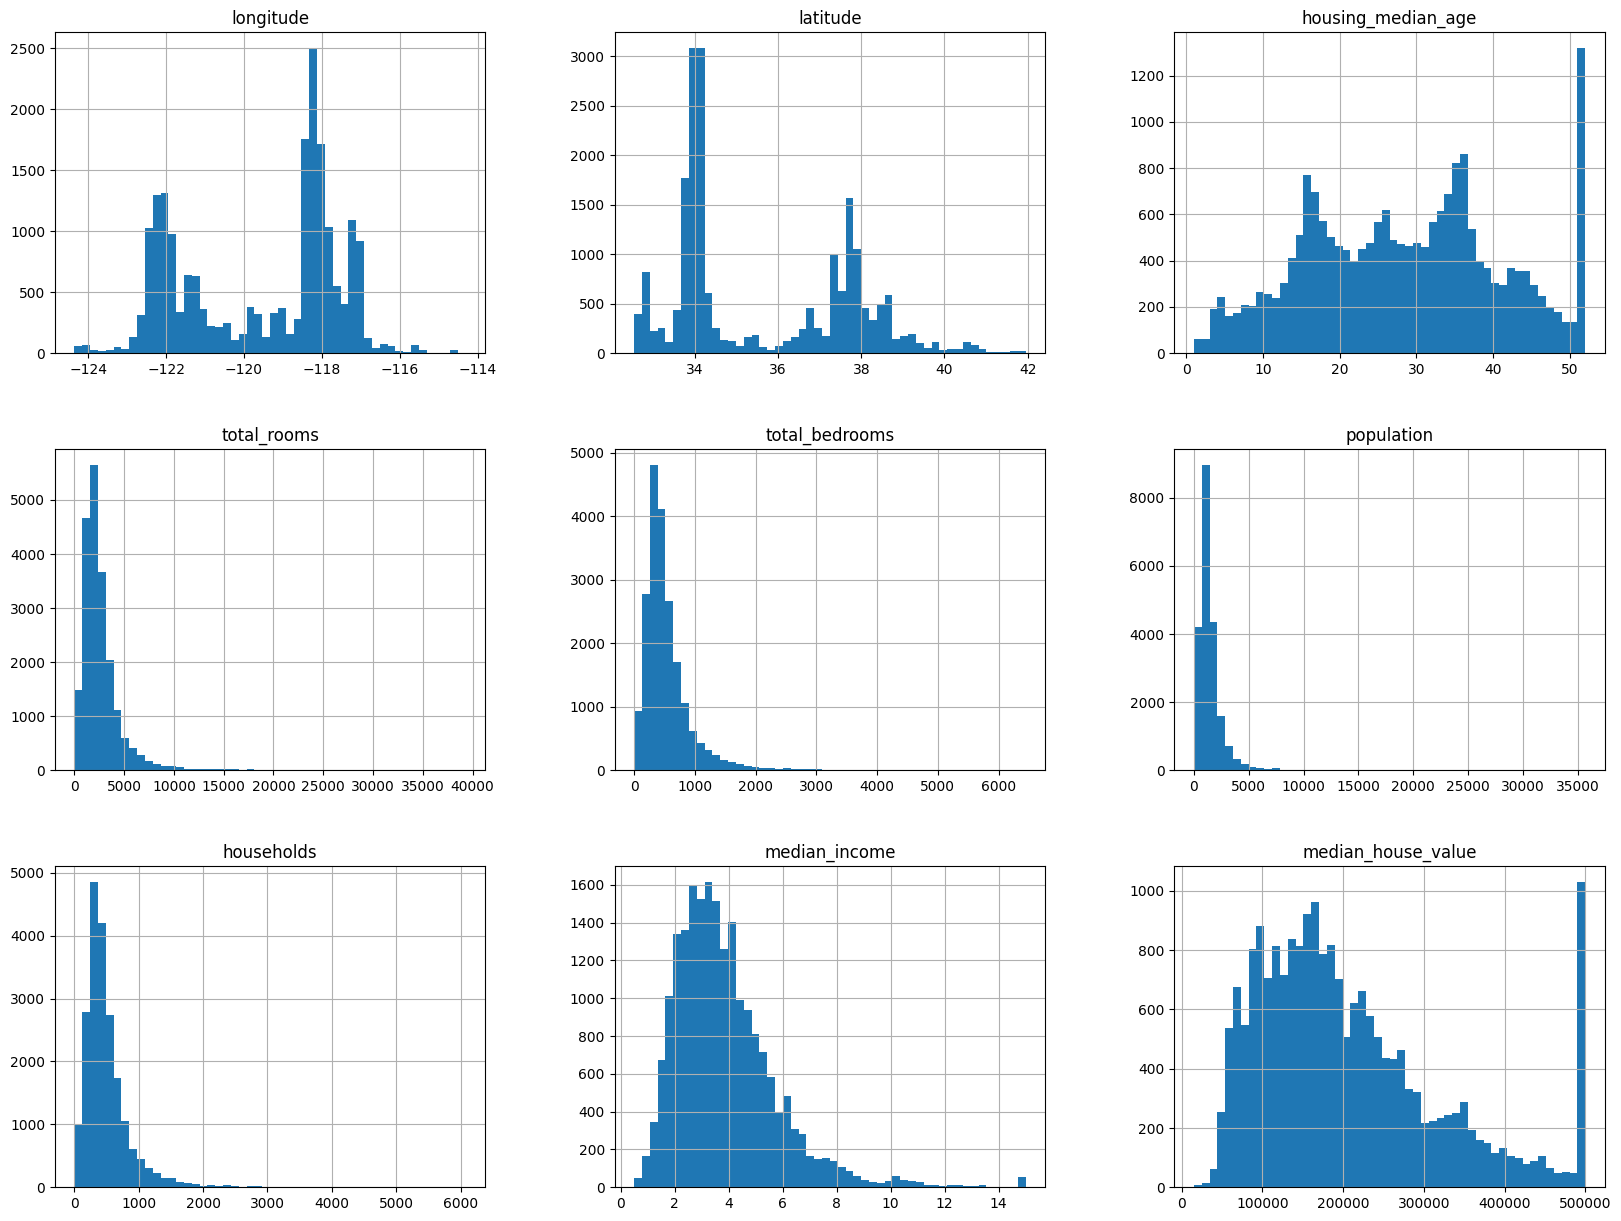

In [ ]:
housing.hist(bins=50,figsize=(20,15))
plt.show()

# Before you look at the data any further, you need to create a test set, put it aside, and never look at it.



In [ ]:
import numpy as np
def shuffle_and_split_data(data, test_ratio):
  shuffled_indices = np.random.permutation(len(data))
  test_set_size = int(len(data) * test_ratio)
  test_indices = shuffled_indices[:test_set_size]
  train_indices = shuffled_indices[test_set_size:]
  return data.iloc[train_indices], data.iloc[test_indices]

In [ ]:
train_set,test_set=shuffle_and_split_data(housing,0.2)
len(train_set)
len(test_set)

4128

Of course! This text explains a critical problem in Machine Learning and a simple, clever solution for dealing with it.

The main concept is ensuring your training set and test set (the data you use to evaluate your model) remain the same even when you update your main dataset.

🧐 The Problem: Unstable Data Splits
When you work with a Machine Learning model, you always split your data into a training set and a test set (e.g., 80% for training, 20% for testing).

The Issue: If you simply split your data randomly, every time you add new data or rerun the split, the set of instances in the test set will change.

The Consequence: This is bad because your model will end up "seeing" a data instance that was previously in the test set, and your performance evaluation will no longer be an accurate measure of how well your model performs on truly new data. You want the test set to be consistent over time.

💡 The Easy Solution: Consistent Hashing (The ID Trick)
The best way to ensure the test set is stable is to use a unique, unchanging value associated with each piece of data, called an instance identifier (ID), to decide which set it belongs to.

How the ID Trick Works:
Get a Unique ID: Every data instance must have a unique ID (like a customer ID or a serial number).

Calculate a Hash: You apply a hash function (like crc32 in the code) to this ID. A hash function converts an input (the ID) into a fixed-size number. The key property is that the same ID will always produce the same hash number.

Set the Threshold: You check if the hash number is below a certain threshold.

If the hash number is below the threshold, you put the data instance in the test set.

If the hash number is above the threshold, you put it in the training set.

The Result: Since the ID for a given instance never changes, and the hash it produces never changes, that instance will always land in the same set (train or test), regardless of when you run the split or how much new data you've added.

In [ ]:
from zlib import crc32
def is_id_in_test_set(identifier, test_ratio):
  return crc32(np.int64(identifier)) < test_ratio * 2**32
def split_data_with_id_hash(data, test_ratio, id_column):
 ids = data[id_column]
 in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_,test_ratio))
 return data.loc[~in_test_set], data.loc[in_test_set]

Unfortunately, the housing dataset does not have an an identifier column. The
simplest solution is to use the row index as the ID:

---



In [ ]:
housing_with_id = housing.reset_index() # adds an `index` column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2,"index")

If you use the row index as a unique identifier, you need to make sure that new
data gets appended to the end of the dataset and that no row ever gets deleted. If
6
this is not possible, then you can try to use the most stable features to build a
unique identifier. For example, a district’s latitude and longitude are guaranteed
to be stable for a few million years, so you could combine them into an ID like
so:

In [ ]:
housing_with_id["id"] = housing["longitude"] * 1000 + housing["latitude"]
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2,"id")


In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2,
random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2,
random_state=42)


Stratified sampling is a probability sampling method where a population is divided into distinct, non-overlapping subgroups called strata based on shared characteristics such as age, gender, income level, or education

. The following code uses the pd.cut()
function to create an income category attribute with five categories (labeled from
1 to 5); category 1 ranges from 0 to 1.5 (i.e., less than $15,000), category 2 from
1.5 to 3, and so on:


In [ ]:
housing["income_cat"]=pd.cut(housing['median_income'],
                             bins=[0.,1.5,3.0,4.5,6.0,np.inf],
                             labels=[1,2,3,4,5])

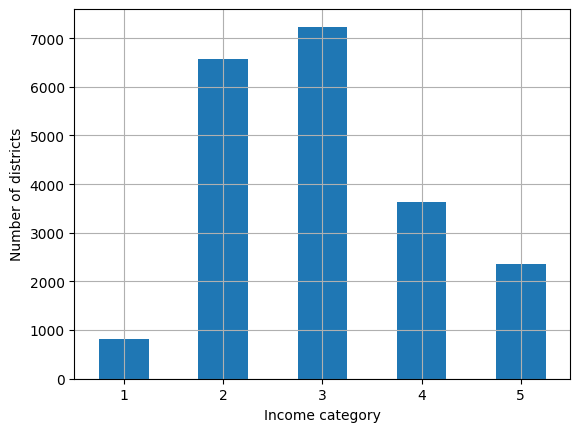

In [ ]:
housing["income_cat"].value_counts().sort_index().plot.bar(rot=0,
grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()

Now you are ready to do stratified sampling based on the income category.
Scikit-Learn provides a number of splitter classes in the
sklearn.model_selection package that implement various strategies to
split your dataset into a training set and a test set. Each splitter has a split()
method that returns an iterator over different training/test splits of the same data.

To be precise, the split() method yields the training and test indices, not the
data itself. Having multiple splits can be useful if you want to better estimate the
performance of your model, as you will see when we discuss cross-validation
later in this chapter. For example, the following code generates 10 different
stratified splits of the same dataset:

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2,
random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing,
  housing["income_cat"]):
  strat_train_set_n = housing.iloc[train_index]
  strat_test_set_n = housing.iloc[test_index]
  strat_splits.append([strat_train_set_n, strat_test_set_n])


In [ ]:
strat_train_set, strat_test_set = strat_splits[0]

since stratified sampling is fairly common, there’s a shorter way to get a
single split using the train_test_split() function with the stratify
argument:

In [ ]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["income_cat"],random_state=42)


In [ ]:
 strat_test_set["income_cat"].value_counts() / len(strat_test_set)

,count
income_cat,
3,0.350533
2,0.318798
4,0.176357
5,0.114341
1,0.039971


You won’t use the income_cat column again, so you might as well drop it,
reverting the data back to its original state:

In [ ]:
for set_ in (strat_train_set, strat_test_set):
  set_.drop("income_cat", axis=1, inplace=True)

We spent quite a bit of time on test set generation for a good reason: this is an
often neglected but critical part of a machine learning project. Moreover, many
of these ideas will be useful later when we discuss cross-validation

First, make sure you have put the test set aside and you are only exploring the
training set. Also, if the training set is very large, you may want to sample an
exploration set, to make manipulations easy and fast during the exploration
phase. In this case, the training set is quite small, so you can just work directly
on the full set. Since you’re going to experiment with various transformations of
the full training set, you should make a copy of the original so you can revert to
it afterwards:


In [ ]:
housing = strat_train_set.copy()

<Axes: xlabel='longitude', ylabel='latitude'>

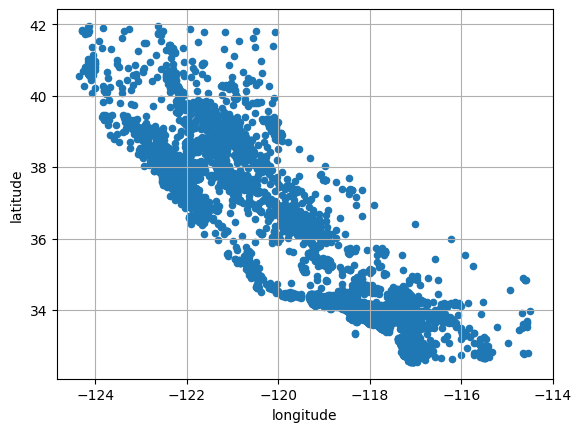

In [ ]:
housing.plot(kind='scatter',x="longitude",y="latitude",grid=True)

but other than that it is hard to see any
particular pattern. Setting the alpha option to 0.2 makes it much easier to
visualize the places where there is a high density of data points

<Axes: xlabel='longitude', ylabel='latitude'>

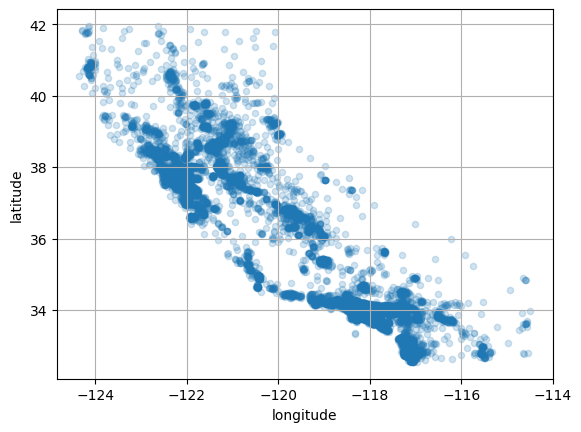

In [ ]:
housing.plot(kind="scatter",x="longitude",y="latitude",grid=True,alpha=0.2)

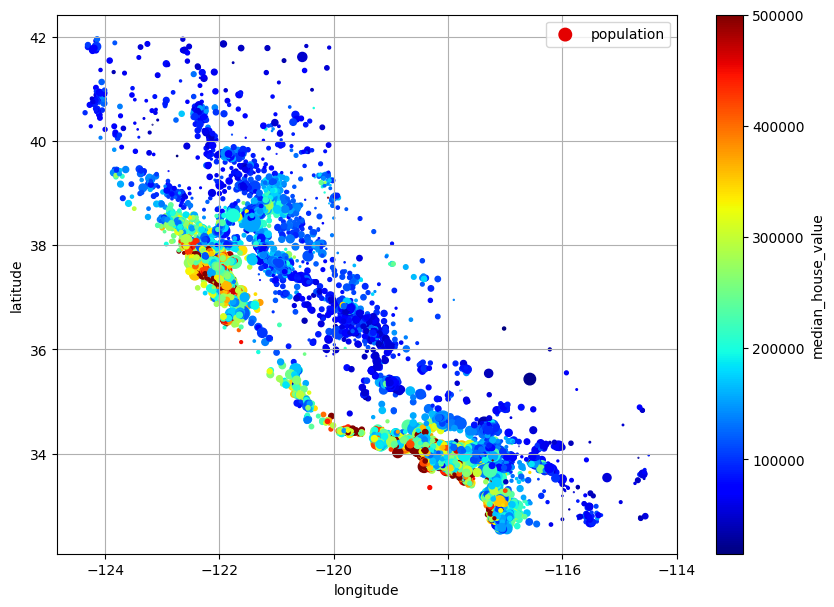

In [ ]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
              s=housing["population"] / 100, label="population",
              c="median_house_value", cmap="jet", colorbar=True,
              legend=True, sharex=False, figsize=(10, 7))
plt.show()


Look for Correlations
Since the dataset is not too large, you can easily compute the standard
correlation coefficient (also called Pearson’s r) between every pair of attributes
using the corr() method:

In [ ]:
corr_matrix=housing.drop("ocean_proximity", axis=1).corr()

In [ ]:
corr_matrix=housing.drop("ocean_proximity", axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_household,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_household,-0.038224
longitude,-0.050859


Another way to check for correlation between attributes is to use the Pandas
scatter_matrix() function, which plots every numerical attribute against
every other numerical attribute. Since there are now 11 numerical attributes, you
would get 11 = 121 plots, which would not fit on a page—so you decide to
focus on a few promising attributes that seem most correlated with the median
housing value

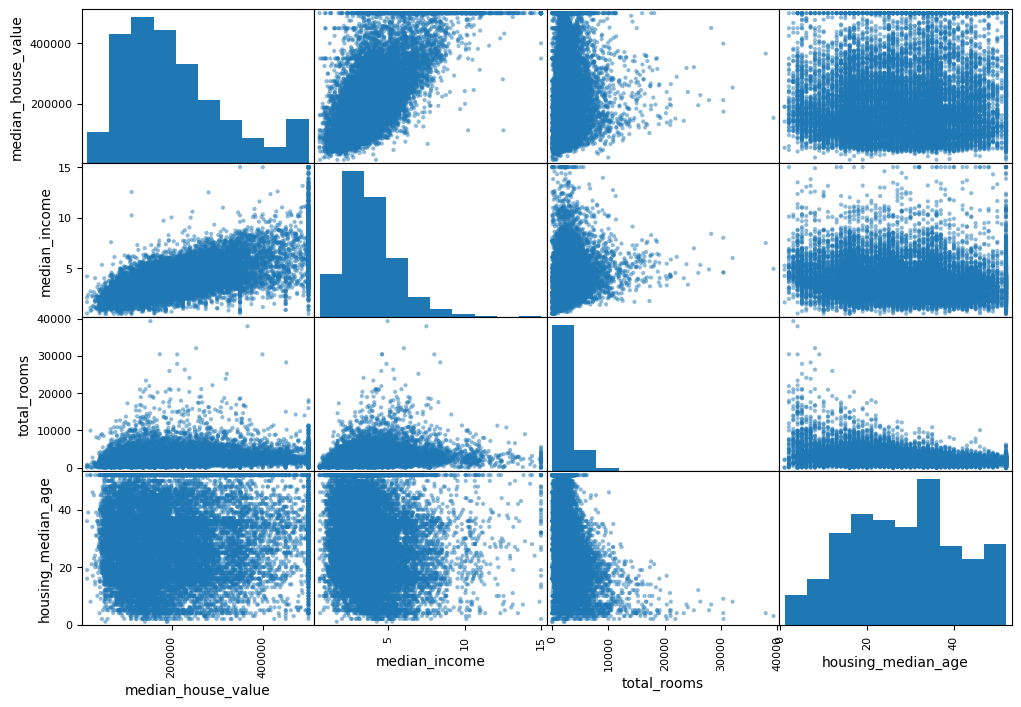

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms",
"housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()


Looking at the correlation scatterplots, it seems like the most promising attribute
to predict the median house value is the median income, so you zoom in on their
scatterplot

<Axes: xlabel='median_income', ylabel='median_house_value'>

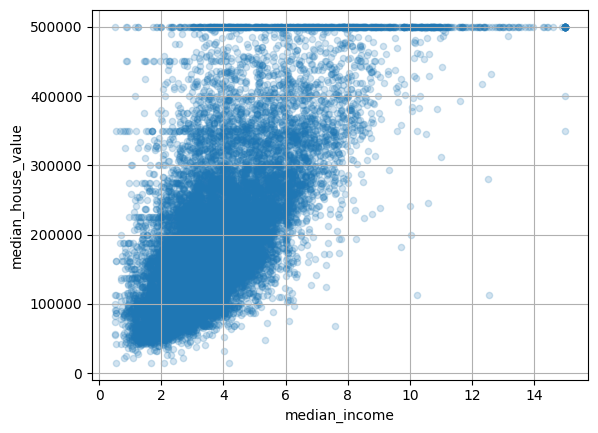

In [ ]:
housing.plot(kind="scatter",x="median_income",y="median_house_value",alpha=0.2,grid=True)

In [ ]:
housing["rooms_per_household"]=housing["total_rooms"]/housing["households"]
housing["bedrooms_ratio"]=housing["total_bedrooms"]/housing["total_rooms"]
housing["people_per_household"]=housing["population"]/housing["households"]

In [ ]:
corr_matrix=housing.drop("ocean_proximity", axis=1).corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

,median_house_value
median_house_value,1.000000
median_income,0.688380
rooms_per_household,0.143663
total_rooms,0.137455
housing_median_age,0.102175
households,0.071426
total_bedrooms,0.054635
population,-0.020153
people_per_household,-0.038224
longitude,-0.050859


Hey, not bad! The new bedrooms_ratio attribute is much more correlated
with the median house value than the total number of rooms or bedrooms.
Apparently houses with a lower bedroom/room ratio tend to be more expensive.
The number of rooms per household is also more informative than the total
number of rooms in a district—obviously the larger the houses, the more
expensive they are.


But first, revert to a clean training set (by copying strat_train_set once
again). You should also separate the predictors and the labels, since you don’t
necessarily want to apply the same transformations to the predictors and the
target values (note that drop() creates a copy of the data and does not affect
strat_train_set):


In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

Most machine learning algorithms cannot work with missing features, so you’ll
need to take care of these. For example, you noticed earlier that the
total_bedrooms attribute has some missing values. You have three options
to fix this:
1. Get rid of the corresponding districts.
2. Get rid of the whole attribute.
3. Set the missing values to some value (zero, the mean, the median, etc.).
This is called imputation.
You can accomplish these easily using the Pandas DataFrame’s dropna(),
drop(), and fillna() methods:

In [ ]:
housing.dropna(subset=["total_bedrooms"], inplace=True) # option 1
housing.drop("total_bedrooms", axis=1) # option 2
median = housing["total_bedrooms"].median() # option 3
housing["total_bedrooms"].fillna(median, inplace=True)

/tmp/ipython-input-2556212778.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(median, inplace=True)


You decide to go for option 3 since it is the least destructive, but instead of the
preceding code, you will use a handy Scikit-Learn class: SimpleImputer.
The benefit is that it will store the median value of each feature: this will make it
possible to impute missing values not only on the training set, but also on the
validation set, the test set, and any new data fed to the model. To use it, first you
need to create a SimpleImputer instance, specifying that you want to replace
each attribute’s missing values with the median of that attribute:

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

Since the median can only be computed on numerical attributes, you then need
to create a copy of the data with only the numerical attributes (this will exclude
the text attribute ocean_proximity):


In [ ]:
housing_num = housing.select_dtypes(include=[np.number])

In [ ]:
imputer.fit(housing_num)

SimpleImputer(strategy='median')

The imputer has simply computed the median of each attribute and stored the
result in its statistics_ instance variable. Only the total_bedrooms
attribute had missing values, but you cannot be sure that there won’t be any
missing values in new data after the system goes live, so it is safer to apply the
imputer to all the numerical attributes:

In [ ]:
imputer.statistics_

housing_num.median().values

array([-118.51  ,   34.26  ,   29.    , 2125.5   ,  434.    , 1167.    ,
        408.5   ,    3.5409])

Now you can use this “trained” imputer to transform the training set by
replacing missing values with the learned medians:

In [ ]:
X = imputer.transform(housing_num)

Missing values can also be replaced with the mean value
(strategy="mean"), or with the most frequent value
(strategy="most_frequent"), or with a constant value
(strategy="constant"
, fill_value=…). The last two strategies
support non-numerical data.


There are also more powerful imputers available in the sklearn.impute package (both for
numerical features only):

KNNImputer replaces each missing value with the mean of the k-nearest neighbors’
values for that feature. The distance is based on all the available features.

IterativeImputer trains a regression model per feature to predict the missing
values based on all the other available features. It then trains the model again on the
updated data, and repeats the process several times, improving the models and the
replacement values at each iteration.